# Understanding Font Rendering

Visualize how `FontRenderer` converts characters to images and the effect of each parameter.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from font2dataset.renderer import FontRenderer, RenderConfig

FONT_REGULAR = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
FONT_BOLD    = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"

def show_images(images, titles, figsize=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize or (2 * n, 2.5))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Ready")

Ready


## 1. Basic Rendering

Default settings: 64×64 px image, font size 48 px.

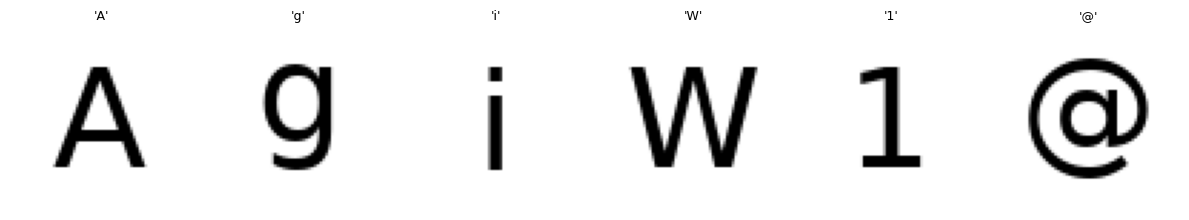

In [2]:
renderer = FontRenderer(FONT_REGULAR)
chars = ["A", "g", "i", "W", "1", "@"]

images = [renderer.render(c) for c in chars]
show_images(images, [f"'{c}'" for c in chars])

## 2. Centering Mechanism

`bbox` from `textbbox` is used to compute the draw offset that centers each glyph.
Red box = glyph bbox, blue lines = image center.

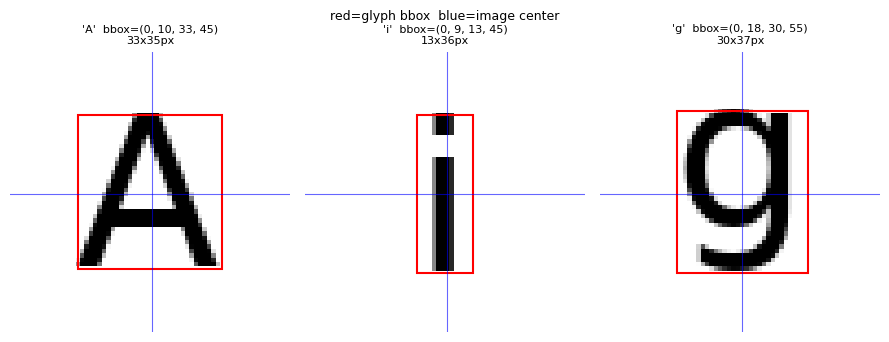

In [3]:
cfg = RenderConfig(image_size=(64, 64), font_size=48)
font = ImageFont.truetype(FONT_REGULAR, cfg.font_size)
h, w = cfg.image_size

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))

for ax, char in zip(axes, ["A", "i", "g"]):
    img = Image.new("RGB", (w, h), "white")
    draw = ImageDraw.Draw(img)

    bbox = draw.textbbox((0, 0), char, font=font)
    char_w = bbox[2] - bbox[0]
    char_h = bbox[3] - bbox[1]
    x = (w - char_w) // 2 - bbox[0]
    y = (h - char_h) // 2 - bbox[1]
    draw.text((x, y), char, font=font, fill="black")

    ax.imshow(img)
    # glyph bounding box in red
    rect = patches.Rectangle(
        (x + bbox[0], y + bbox[1]), char_w, char_h,
        linewidth=1.5, edgecolor="red", facecolor="none"
    )
    ax.add_patch(rect)
    # image center in blue
    ax.axhline(h / 2, color="blue", linewidth=0.8, alpha=0.6)
    ax.axvline(w / 2, color="blue", linewidth=0.8, alpha=0.6)
    ax.set_title(f"'{char}'  bbox={bbox}\n{char_w}x{char_h}px", fontsize=8)
    ax.axis("off")

plt.suptitle("red=glyph bbox  blue=image center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Effect of Font Size

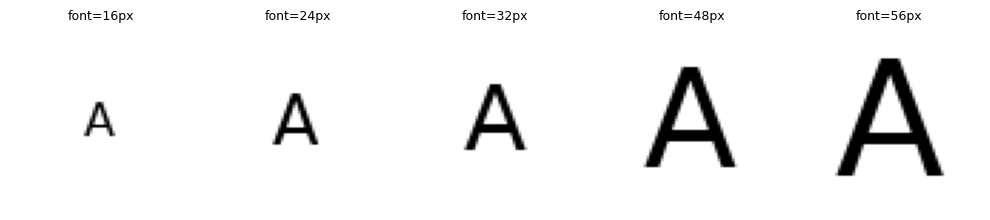

In [4]:
font_sizes = [16, 24, 32, 48, 56]
images, titles = [], []

for fs in font_sizes:
    r = FontRenderer(FONT_REGULAR, RenderConfig(image_size=(64, 64), font_size=fs))
    images.append(r.render("A"))
    titles.append(f"font={fs}px")

show_images(images, titles)

## 4. Overflow Modes

`fits()` checks whether a character fits in the padded area.
When it does not fit, the behaviour is controlled by `overflow`.

| `overflow` | Behaviour |
|-----------|-----------|
| `"skip"` | Return `None` (default) |
| `"shrink"` | Reduce font size until the character fits |
| `"scale"` | Render at natural size then downscale, preserving aspect ratio |

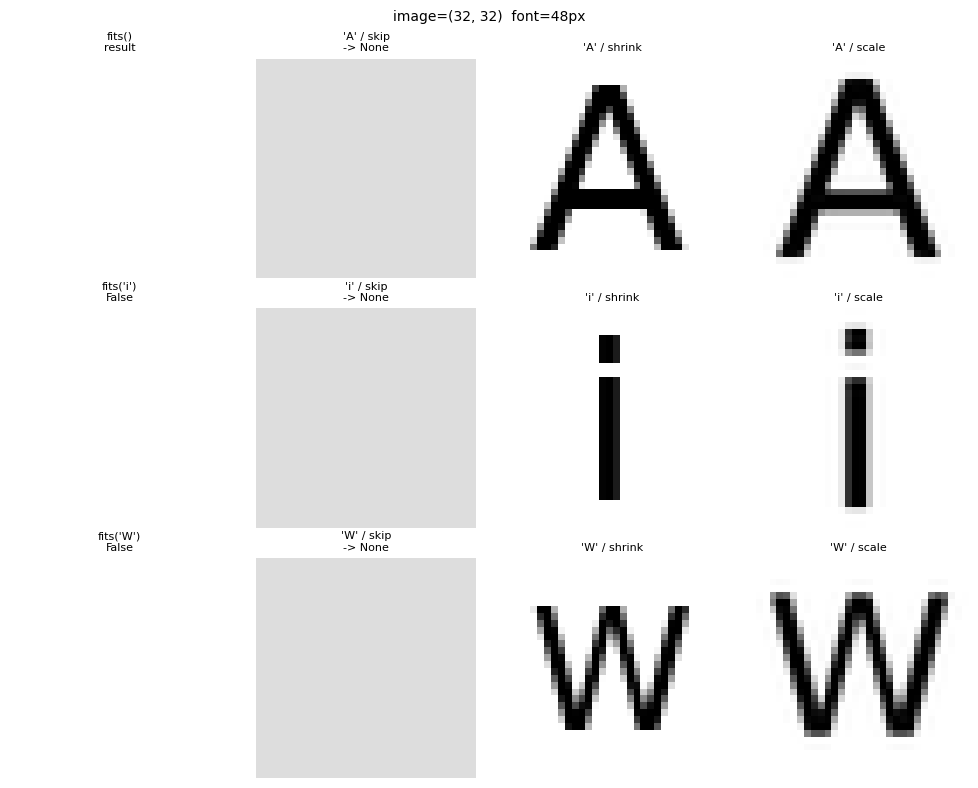

In [5]:
image_size = (32, 32)
font_size  = 48
chars = ["A", "i", "W"]
modes = ["skip", "shrink", "scale"]

fig, axes = plt.subplots(len(chars), len(modes) + 1, figsize=(10, 8))

for row, char in enumerate(chars):
    r_ref = FontRenderer(FONT_REGULAR, RenderConfig(image_size=image_size, font_size=font_size, overflow="skip"))
    is_fit = r_ref.fits(char)

    dummy_img = Image.new("RGB", image_size[::-1], "white")
    axes[row][0].imshow(dummy_img)
    axes[row][0].set_title(f"fits('{char}')\n{'True' if is_fit else 'False'}", fontsize=8)
    axes[row][0].axis("off")

    for col, mode in enumerate(modes, start=1):
        r = FontRenderer(FONT_REGULAR, RenderConfig(
            image_size=image_size, font_size=font_size,
            overflow=mode, min_font_size=6
        ))
        img = r.render(char)
        ax = axes[row][col]
        if img is None:
            blank = Image.new("RGB", image_size[::-1], "#dddddd")
            ax.imshow(blank)
            ax.set_title(f"'{char}' / {mode}\n-> None", fontsize=8)
        else:
            ax.imshow(img)
            ax.set_title(f"'{char}' / {mode}", fontsize=8)
        ax.axis("off")

axes[0][0].set_title("fits()\nresult", fontsize=8)
plt.suptitle(f"image={image_size}  font={font_size}px", fontsize=10)
plt.tight_layout()
plt.show()

## 5. bbox_method: `textbbox` vs `pixel`

`textbbox` uses font metrics (advance width); `pixel` detects actual ink pixels from the rendered image.

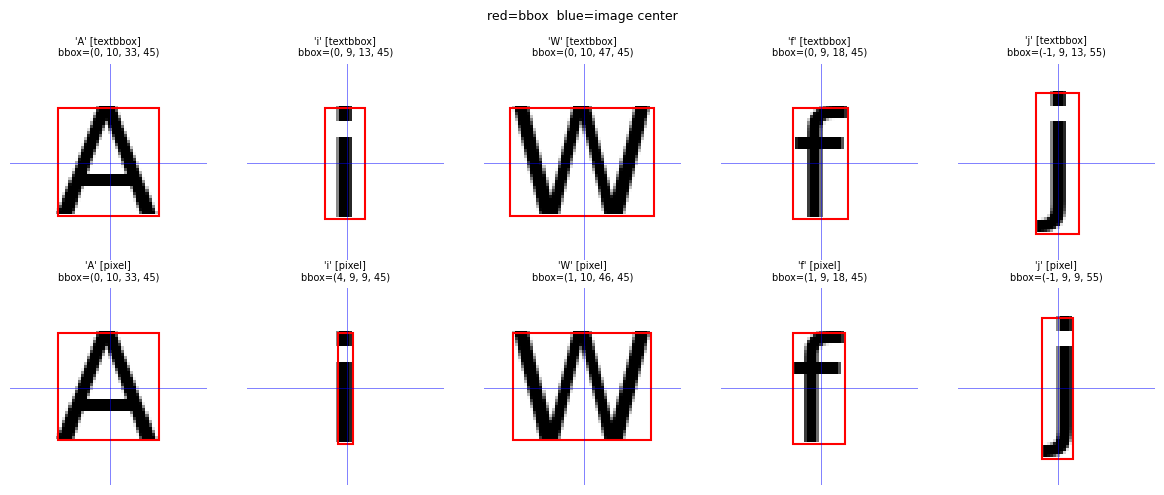

char              textbbox                 pixel  diff(left,top,right,bottom)
  'A'       (0, 10, 33, 45)       (0, 10, 33, 45)  (0, 0, 0, 0)
  'i'        (0, 9, 13, 45)         (4, 9, 9, 45)  (4, 0, -4, 0)
  'W'       (0, 10, 47, 45)       (1, 10, 46, 45)  (1, 0, -1, 0)
  'f'        (0, 9, 18, 45)        (1, 9, 18, 45)  (1, 0, 0, 0)
  'j'       (-1, 9, 13, 55)        (-1, 9, 9, 55)  (0, 0, -4, 0)


In [6]:
import matplotlib.patches as patches2

chars = ["A", "i", "W", "f", "j"]
fig, axes = plt.subplots(2, len(chars), figsize=(12, 5))

for col, char in enumerate(chars):
    for row, method in enumerate(["textbbox", "pixel"]):
        r = FontRenderer(FONT_REGULAR, RenderConfig(
            image_size=(64, 64), font_size=48, bbox_method=method
        ))
        img = r.render(char)
        _, _, bbox = r._char_size(char, r._font)
        char_w = bbox[2] - bbox[0]
        char_h = bbox[3] - bbox[1]
        x, y = r.calc_xy(char)

        ax = axes[row][col]
        ax.imshow(img)
        rect = patches2.Rectangle(
            (x + bbox[0], y + bbox[1]), char_w, char_h,
            linewidth=1.5, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        ax.axhline(32, color="blue", linewidth=0.7, alpha=0.5)
        ax.axvline(32, color="blue", linewidth=0.7, alpha=0.5)
        ax.set_title(f"'{char}' [{method}]\nbbox={bbox}", fontsize=7)
        ax.axis("off")

plt.suptitle("red=bbox  blue=image center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'char':>4}  {'textbbox':>20}  {'pixel':>20}  diff(left,top,right,bottom)")
for char in chars:
    r_tb = FontRenderer(FONT_REGULAR, RenderConfig(bbox_method="textbbox"))
    r_px = FontRenderer(FONT_REGULAR, RenderConfig(bbox_method="pixel"))
    _, _, tb = r_tb._char_size(char, r_tb._font)
    _, _, px = r_px._char_size(char, r_px._font)
    diff = tuple(p - t for p, t in zip(px, tb))
    print(f"  '{char}'  {str(tb):>20}  {str(px):>20}  {diff}")

## 6. Resampling Algorithm — `resample`

Choose the interpolation filter used when `overflow="scale"` resizes the image.
Pillow provides six options via `Image.Resampling`.

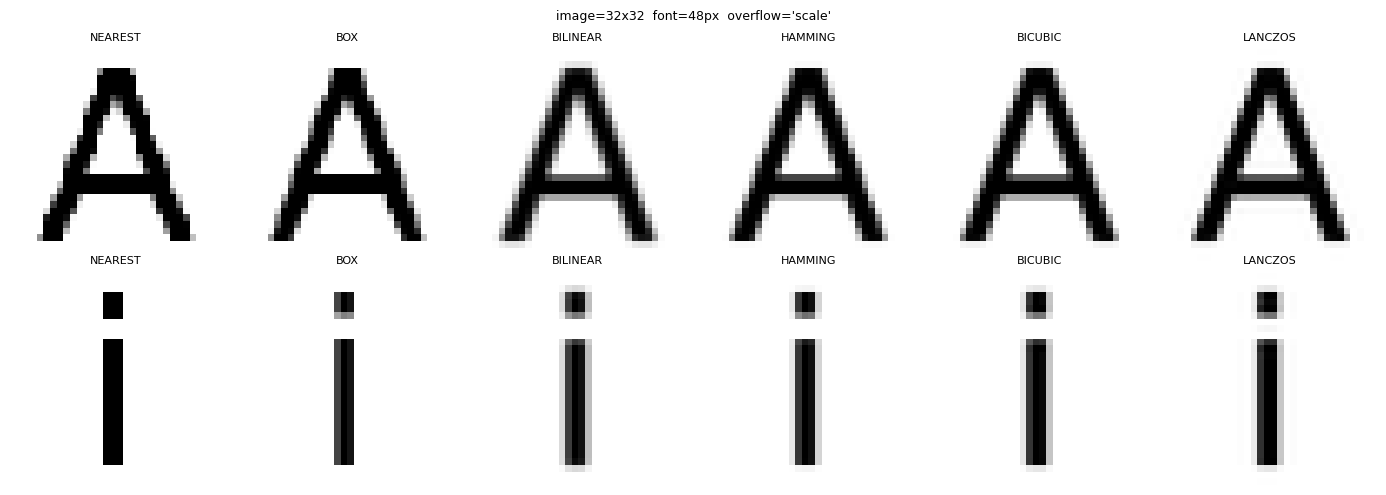

MAE relative to LANCZOS:
  NEAREST     : 6.65
  BOX         : 5.17
  BILINEAR    : 2.82
  HAMMING     : 1.90
  BICUBIC     : 0.81
  LANCZOS     : 0.00


In [7]:
algos = list(Image.Resampling)
chars = ["A", "i"]

fig, axes = plt.subplots(len(chars), len(algos), figsize=(14, 5))

for row, char in enumerate(chars):
    for col, algo in enumerate(algos):
        r = FontRenderer(FONT_REGULAR, RenderConfig(
            image_size=(32, 32), font_size=48,
            overflow="scale", resample=algo
        ))
        img = r.render(char)
        axes[row][col].imshow(img)
        axes[row][col].set_title(algo.name, fontsize=8)
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(f"'{char}'", fontsize=10)

plt.suptitle("image=32x32  font=48px  overflow='scale'", fontsize=9)
plt.tight_layout()
plt.show()

# MAE relative to LANCZOS
r_ref = FontRenderer(FONT_REGULAR, RenderConfig(
    image_size=(32, 32), font_size=48, overflow="scale",
    resample=Image.Resampling.LANCZOS
))
ref = np.array(r_ref.render("A"), dtype=float)
print("MAE relative to LANCZOS:")
for algo in algos:
    r = FontRenderer(FONT_REGULAR, RenderConfig(
        image_size=(32, 32), font_size=48, overflow="scale", resample=algo
    ))
    arr = np.array(r.render("A"), dtype=float)
    mae = np.abs(arr - ref).mean()
    print(f"  {algo.name:12}: {mae:.2f}")

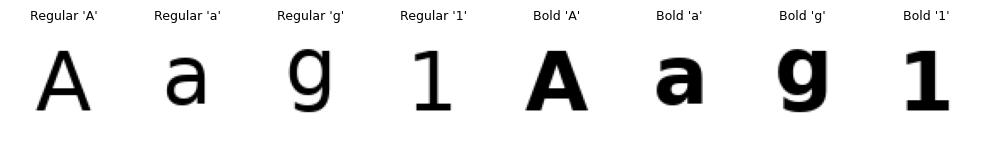

In [8]:
cfg = RenderConfig(image_size=(64, 64), font_size=48)
r_regular = FontRenderer(FONT_REGULAR, cfg)
r_bold    = FontRenderer(FONT_BOLD, cfg)

chars = ["A", "a", "g", "1"]
images = [r_regular.render(c) for c in chars] + [r_bold.render(c) for c in chars]
titles = [f"Regular '{c}'" for c in chars] + [f"Bold '{c}'" for c in chars]

show_images(images, titles, figsize=(10, 5))

## 7. Regular vs Bold

## 8. Background and Foreground Colors

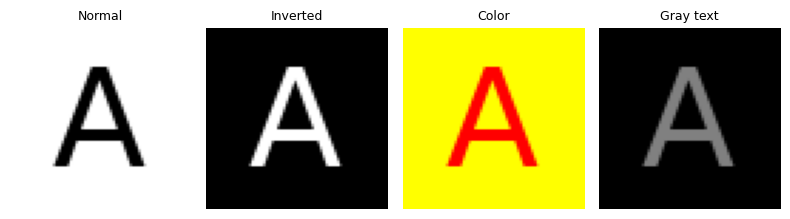

In [9]:
styles = [
    ("white",  "black",  "Normal"),
    ("black",  "white",  "Inverted"),
    ("yellow", "red",    "Color"),
    ("black",  "gray",   "Gray text"),
]

images, titles = [], []
for bg, fg, label in styles:
    r = FontRenderer(FONT_REGULAR, RenderConfig(background=bg, foreground=fg))
    images.append(r.render("A"))
    titles.append(label)

show_images(images, titles)

## 9. `render_batch` — Batch Rendering

Characters that return `None` (overflow="skip") are automatically dropped from the output.

Input : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
Output: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']  (10/10)


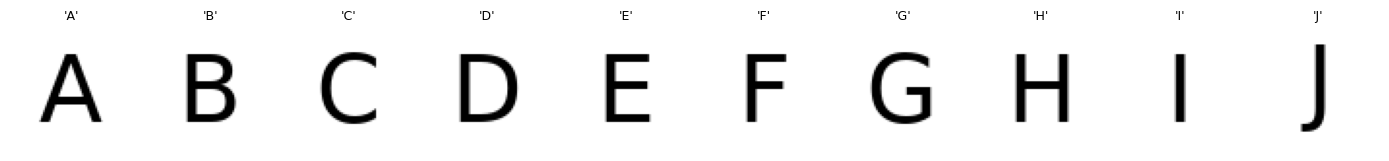

In [10]:
cfg = RenderConfig(image_size=(64, 64), font_size=48, overflow="skip")
renderer = FontRenderer(FONT_REGULAR, cfg)

ascii_chars = list("ABCDEFGHIJ")
results = renderer.render_batch(ascii_chars)  # None results are silently skipped

print(f"Input : {ascii_chars}")
print(f"Output: {[c for c, _ in results]}  ({len(results)}/{len(ascii_chars)})")
show_images([img for _, img in results], [f"'{c}'" for c, _ in results], figsize=(14, 2.5))

## Summary

| Topic | Result |
|-------|--------|
| Centering | Offset computed from `bbox` via `textbbox` or pixel detection |
| `padding` | Shrinks the effective area so glyphs don't touch the image edge |
| Overflow | Controlled by `overflow`: `skip` / `shrink` / `scale` |
| `bbox_method="textbbox"` | Fast and stable; based on font metrics |
| `bbox_method="pixel"` | Precise ink bounds; useful for decorative fonts |
| `resample` | Interpolation filter for `overflow="scale"`; `LANCZOS` = highest quality, `NEAREST` = fastest |
| Regular vs Bold | `weight_class` 400 vs 700 reflects stroke width difference |
| Colors | `background` / `foreground` in `RenderConfig` |